# Aplikacja DnoOka - porównanie trzech metod

## 1. Środowisko i modele

In [15]:
import sys, time, traceback
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print('[INFO] ipywidgets nie jest zainstalowany.')

from src import io_utils, metrics, visualize
from src import baseline, classical_ml, unet
from src.config import TEST_IMAGES, MODELS_DIR, REPORT_DIR

device = unet.get_device()

### Wczytanie modeli

In [16]:
rf_path = MODELS_DIR / 'rf.joblib'
unet_path = MODELS_DIR / 'unet.pt'

if not rf_path.exists():
    print(f'[WARN] {rf_path} nie znaleziony - uruchom 02_classical_ml.ipynb')
    rf_model = None
else:
    rf_model = classical_ml.load_model(rf_path)
    print(f'RF loaded:    {rf_path}')

if not unet_path.exists():
    print(f'[WARN] {unet_path} nie znaleziony - uruchom 03_deep_learning.ipynb')
    unet_model = None
else:
    unet_model = unet.load_model(unet_path, device=device)
    print(f'U-Net loaded: {unet_path}  ({device})')

RF loaded:    /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/rf.joblib
U-Net loaded: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/unet.pt  (mps)


### Wspólne API predykcji

In [17]:
RF_STRIDE   = 2
UNET_TILE   = 256
UNET_OVER   = 32
UNET_THR    = 0.5

def predict_baseline(rgb, fov):
    return baseline.predict_mask(rgb, fov)

def predict_rf(rgb, fov):
    if rf_model is None:
        raise RuntimeError('rf_model nie wczytany - uruchom 02_classical_ml.ipynb')
    return classical_ml.predict_mask(rf_model, rgb, fov, stride=RF_STRIDE, progress=False)

def predict_unet(rgb, fov):
    if unet_model is None:
        raise RuntimeError('unet_model nie wczytany - uruchom 03_deep_learning.ipynb')
    return unet.predict_mask(
        unet_model, rgb, fov, device=device,
        tile_size=UNET_TILE, overlap=UNET_OVER, threshold=UNET_THR,
    )

PREDICTORS = {
    'baseline (Frangi)':  predict_baseline,
    'random_forest':      predict_rf,
    'unet':               predict_unet,
}
COLORS = {
    'baseline (Frangi)':  (255, 0, 0),       # czerwony
    'random_forest':      (0, 200, 0),       # zielony
    'unet':               (0, 100, 255),     # niebieski
}
print('Dostępne predictors:', list(PREDICTORS.keys()))

Dostępne predictors: ['baseline (Frangi)', 'random_forest', 'unet']


### Cache predykcji

In [18]:
# Klucz: (image_id, method) -> uint8 mask. Wypełniany w trakcie obliczeń.
pred_cache: dict[tuple[str, str], np.ndarray] = {}

def cached_predict(image_id: str, method: str):
    """Zwraca (img, gt, fv, pred) z cache na masce predykcji."""
    img, gt, fv = io_utils.load_triplet(image_id)
    key = (image_id, method)
    if key not in pred_cache:
        pred_cache[key] = PREDICTORS[method](img, fv)
    return img, gt, fv, pred_cache[key]

## 2. Aplikacja interaktywna

Wybór obrazu + metody -> wynik + metryki.

In [19]:
if HAVE_WIDGETS:
    image_dd = widgets.Dropdown(options=list(TEST_IMAGES), description='Image:')
    method_dd = widgets.Dropdown(options=list(PREDICTORS.keys()), description='Method:')
    run_btn  = widgets.Button(description='Run', button_style='primary')
    out_area = widgets.Output()

    def on_run_clicked(_):
        run_btn.disabled = True
        original_desc = run_btn.description
        run_btn.description = 'Running...'
        out_area.clear_output(wait=True)
        try:
            with out_area:
                image_id = image_dd.value
                method = method_dd.value
                cached = (image_id, method) in pred_cache
                print(f'-> {method} on {image_id} ' + ('(cached)' if cached else '...'))
                t0 = time.time()
                try:
                    img, gt, fv, pred = cached_predict(image_id, method)
                except Exception as e:
                    print(f'Błąd: {e}')
                    traceback.print_exc()
                    return
                elapsed = time.time() - t0
                m = metrics.compute_metrics(pred, gt, fv)
                print(f'  zajęło {elapsed:.1f}s')
                print()
                for k in ['accuracy', 'sensitivity', 'specificity',
                          'precision', 'g_mean']:
                    print(f'  {k:20s} = {m[k]:.4f}')
                fig = visualize.compare_grid([
                    ('Original', img),
                    ('Ground truth', gt * 255),
                    (f'{method} prediction', pred * 255),
                    ('Overlay', visualize.overlay(img, pred, color=COLORS[method], alpha=0.6)),
                ], ncols=4, suptitle=f'{image_id} - {method}', figsize_per_panel=(4, 4))
                plt.show()
        finally:
            run_btn.disabled = False
            run_btn.description = original_desc

    run_btn.on_click(on_run_clicked)
    display(widgets.HBox([image_dd, method_dd, run_btn]), out_area)
else:
    print('Sekcja 2 pominięta (brak ipywidgets).')

Output()

## 3. Zbiorcze porównanie trzech metod

In [ ]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

rows = [] # [{image, method, accuracy, ...}]
skipped = [] # tu odkładamy (image_id, method, reason) dla nieobliczonych

for image_id in tqdm(TEST_IMAGES, desc='images'):
    for method in PREDICTORS:
        try:
            img, gt, fv, pred = cached_predict(image_id, method)
        except RuntimeError as e:
            skipped.append((image_id, method, str(e)))
            continue
        m = metrics.compute_metrics(pred, gt, fv)
        rows.append({'image': image_id, 'method': method, **m})
        # print(f'  {image_id:8s} {method:20s}  '
        #       f'acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
        #       f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

if skipped:
    print('\nPominięte (model nie wczytany):')
    for image_id, method, reason in skipped:
        print(f'  {image_id}/{method}: {reason}')

df = pd.DataFrame(rows)
# df.head()

images:   0%|          | 0/6 [00:00<?, ?it/s]

/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

### 3.1 Średnie po metodach

In [21]:
summary = df.groupby('method')[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean']
].agg(['mean', 'std']).round(4)
summary

accuracy         sensitivity         specificity          \
                      mean     std        mean     std        mean     std   
method                                                                       
baseline (Frangi)   0.9094  0.0245      0.6645  0.0462      0.9332  0.0273   
random_forest       0.8755  0.0383      0.7659  0.0773      0.8865  0.0493   
unet                0.9629  0.0078      0.8165  0.0256      0.9772  0.0086   

                  precision          g_mean          
                       mean     std    mean     std  
method                                               
baseline (Frangi)    0.5091  0.1123  0.7870  0.0295  
random_forest        0.4216  0.1098  0.8219  0.0212  
unet                 0.7786  0.0835  0.8932  0.0154

### 3.2 Tabela per-image × per-method

In [22]:
pivot = df.set_index(['image', 'method'])[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean']
].round(4)
pivot

accuracy  sensitivity  specificity  precision  g_mean
image method                                                                  
14_h  baseline (Frangi)    0.9018       0.7381       0.9206     0.5173  0.8243
      random_forest        0.8870       0.7809       0.8992     0.4716  0.8380
      unet                 0.9692       0.8488       0.9830     0.8523  0.9134
15_h  baseline (Frangi)    0.9363       0.6598       0.9645     0.6554  0.7977
      random_forest        0.9257       0.6668       0.9522     0.5877  0.7968
      unet                 0.9760       0.8229       0.9916     0.9095  0.9033
14_dr baseline (Frangi)    0.8953       0.5964       0.9250     0.4414  0.7428
      random_forest        0.8533       0.7813       0.8604     0.3574  0.8199
      unet                 0.9577       0.7851       0.9748     0.7561  0.8749
15_dr baseline (Frangi)    0.8711       0.6542       0.8893     0.3314  0.7627
      random_forest        0.8349       0.8463       0.8340     0.2994  0.8401
      unet                 0.9591       0.8339       0.9696     0.6972  0.8992
14_g  baseline (Frangi)    0.9229       0.6845       0.9446     0.5300  0.8041
      random_forest        0.9116       0.6793       0.9328     0.4797  0.7960
      unet                 0.9587       0.7869       0.9744     0.7368  0.8756
15_g  baseline (Frangi)    0.9288       0.6540       0.9549     0.5792  0.7903
      random_forest        0.8406       0.8407       0.8405     0.3335  0.8406
      unet                 0.9568       0.8216       0.9697     0.7200  0.8926

### 3.3 Siatka wizualna

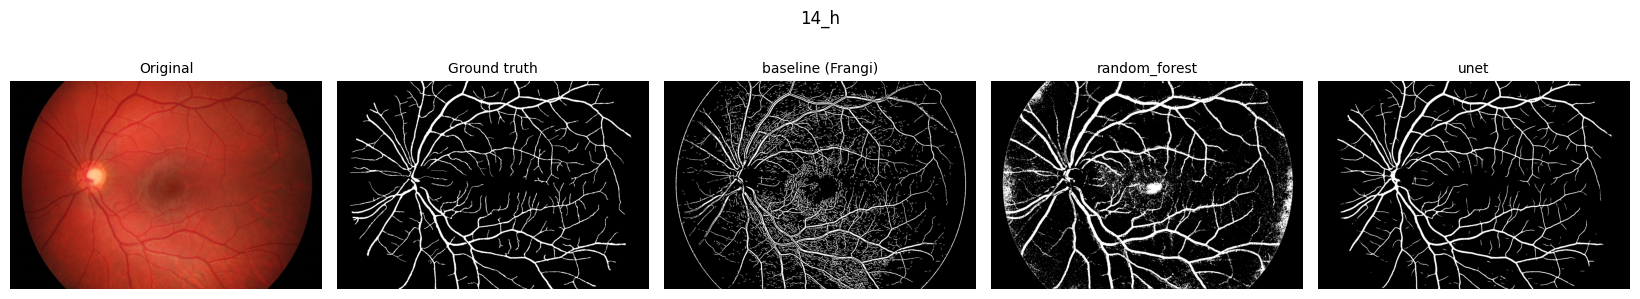

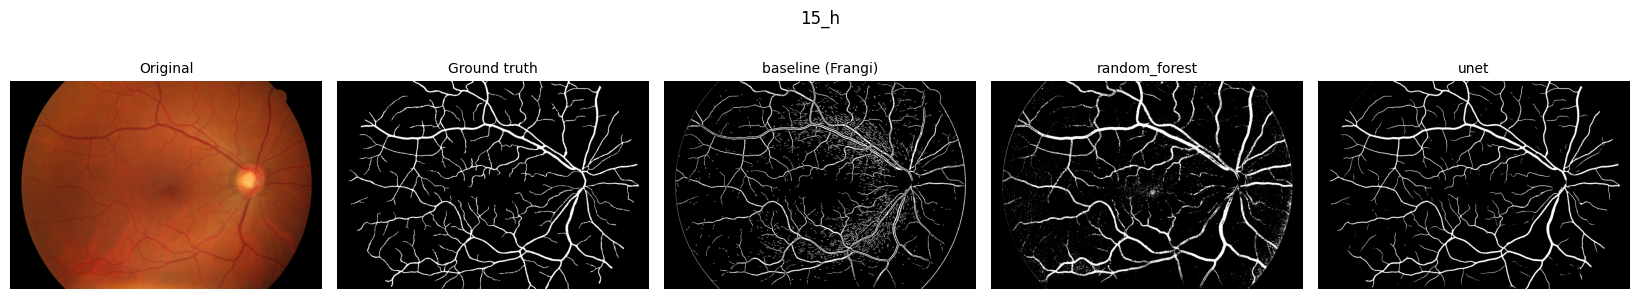

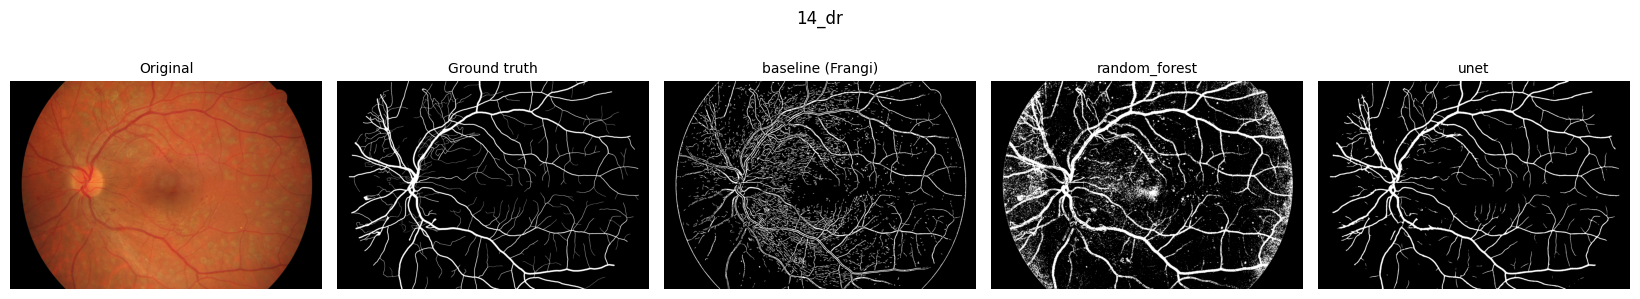

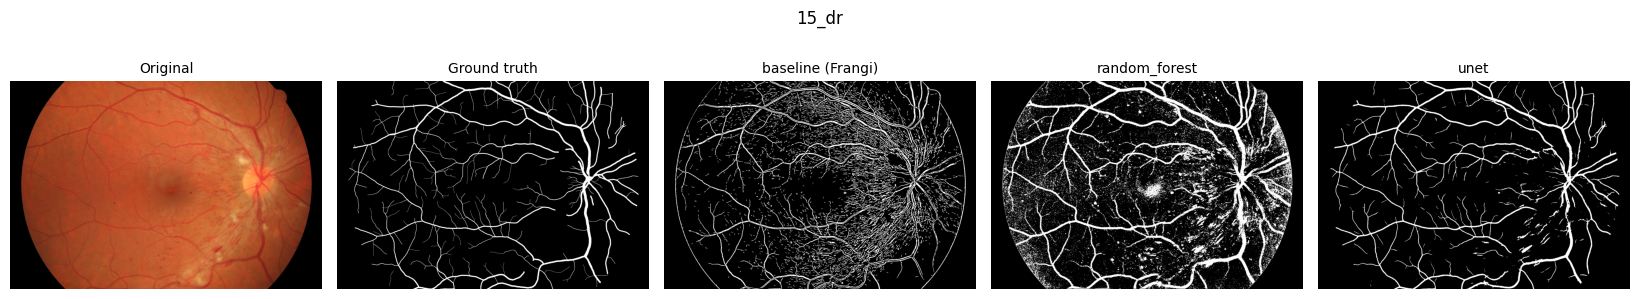

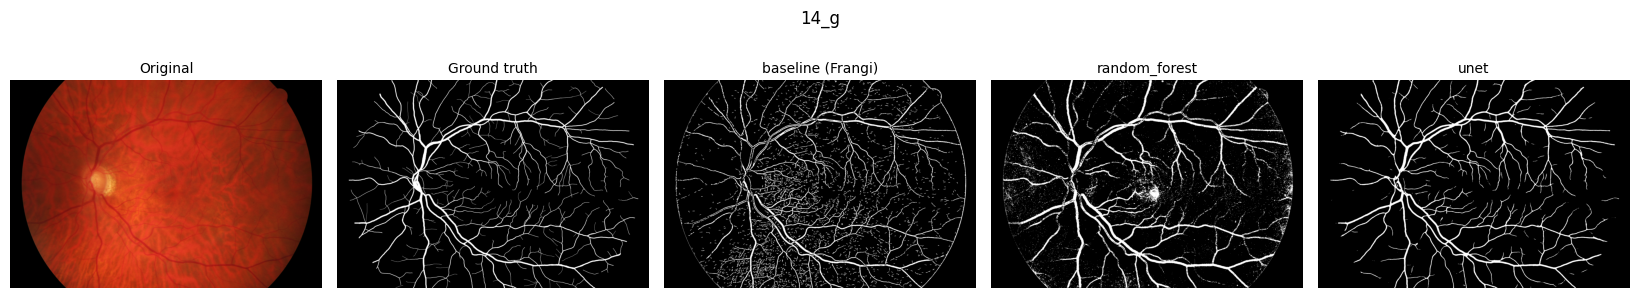

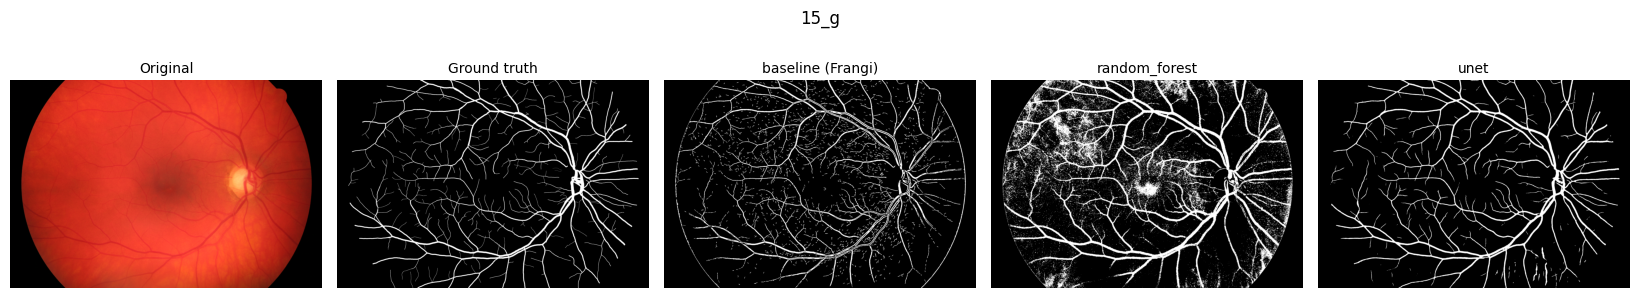


Obrazy zapisane w /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/report/figs


In [23]:
figs_dir = REPORT_DIR / 'figs'
figs_dir.mkdir(parents=True, exist_ok=True)
method_order = list(PREDICTORS.keys())

for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    panels = [('Original', img), ('Ground truth', gt * 255)]
    for method in method_order:
        key = (image_id, method)
        if key in pred_cache:
            panels.append((method, pred_cache[key] * 255))
    fig = visualize.compare_grid(panels, ncols=len(panels),
                                 suptitle=image_id, figsize_per_panel=(3.3, 3.3))
    fig.savefig(figs_dir / f'{image_id}.png', dpi=120, bbox_inches='tight')
    plt.show()
print(f'\nObrazy zapisane w {figs_dir}')

### 3.4 Bar chart: średnie po metodach

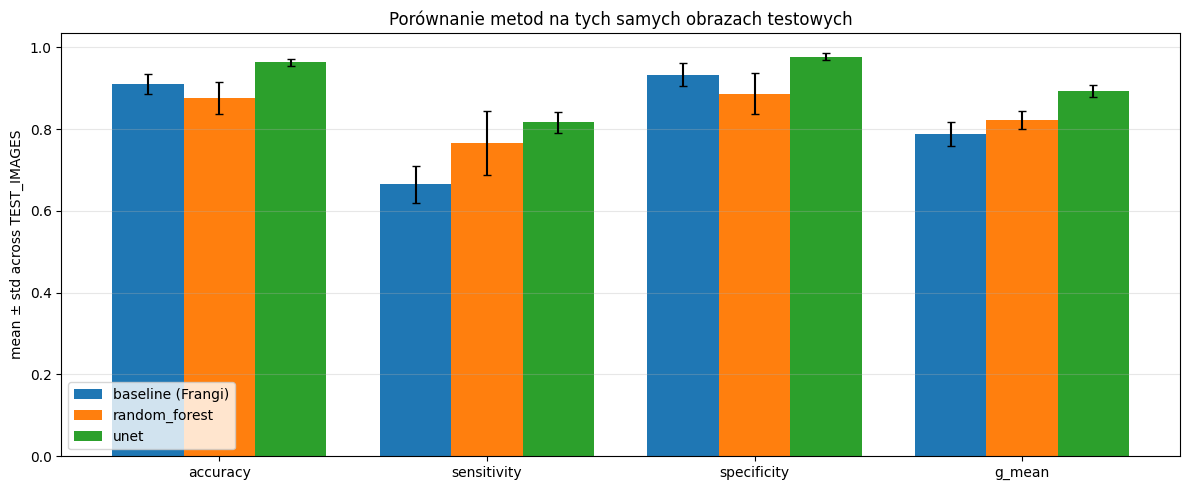

In [24]:
metric_keys = ['accuracy', 'sensitivity', 'specificity', 'g_mean']
means = df.groupby('method')[metric_keys].mean()
stds  = df.groupby('method')[metric_keys].std()
n_methods = len(means.index)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metric_keys))
width = 0.8 / max(n_methods, 1)
for i, method in enumerate(means.index):
    # Centrujemy grupę słupków wokół każdego x.
    offset = (i - (n_methods - 1) / 2) * width
    ax.bar(x + offset, means.loc[method].values, width,
           yerr=stds.loc[method].values, label=method, capsize=3)
ax.set_xticks(x); ax.set_xticklabels(metric_keys)
ax.set_ylabel('mean ± std across TEST_IMAGES')
ax.set_title('Porównanie metod na tych samych obrazach testowych')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Eksport do `report/comparison.md`

In [25]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
comp_path = REPORT_DIR / 'comparison.md'

lines = ['# Porównanie metod na TEST_IMAGES\n']
lines.append('Obrazy testowe: ' + ', '.join(TEST_IMAGES) + '\n')
lines.append('## Tabela zbiorcza (mean ± std po obrazach testowych)\n')
lines.append(means.round(4).to_markdown())
lines.append('\n## Per-image × per-method\n')
lines.append(pivot.to_markdown())
comp_path.write_text('\n'.join(lines))
print(f'Zapisano: {comp_path}')

Zapisano: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/report/comparison.md
